<a href="https://colab.research.google.com/github/pavan-dot-k/Real-Estate-Price-Prediction/blob/main/Crime_Lag_effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Correlation Results:
 Current         -0.016112
6 Months Ago    -0.013623
12 Months Ago   -0.012364
18 Months Ago   -0.012113
24 Months Ago   -0.015141
Name: avg_house_price, dtype: float64


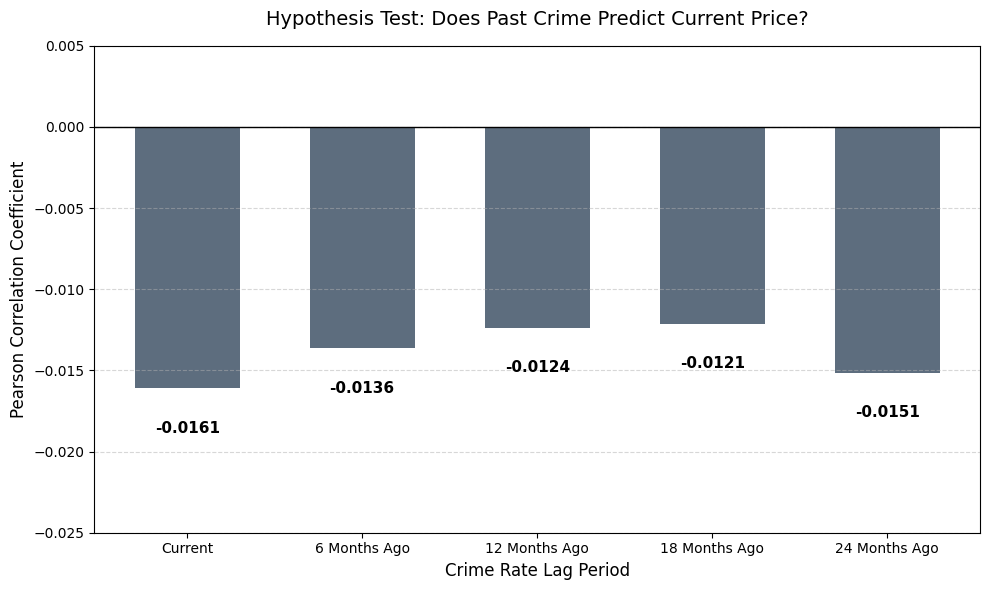

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('dataset_for_training.csv', na_values=['N/A'])

# 2. Preprocess
# Convert date
if 'month/year' in df.columns:
    df['date'] = pd.to_datetime(df['month/year'], format='%m/%Y')

if 'ZHVI' in df.columns:
    df = df.rename(columns={'ZHVI': 'avg_house_price'})

# CRITICAL: Sort by Zip and Date to ensure lags are correct
df = df.sort_values(by=['zip', 'date'])

# Numeric conversion
numeric_cols = ['crime_rate_per_1000', 'avg_house_price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute missing crime data with Median (Standard Pavan Method)
df['crime_rate_per_1000'] = df['crime_rate_per_1000'].fillna(df['crime_rate_per_1000'].median())

# Drop rows where target is missing
df = df.dropna(subset=['avg_house_price'])

# 3. Create Lags (The Experiment)
# We shift the crime rate BACKWARDS to see if past crime predicts current price
lags = [6, 12, 18, 24]
for lag in lags:
    # Group by zip so we don't shift crime from one city to another
    df[f'Crime_{lag}Mo_Ago'] = df.groupby('zip')['crime_rate_per_1000'].shift(lag)

# 4. Calculate Correlations
# We compare Current Price vs. Current Crime, and Current Price vs. Past Crime
corr_cols = ['crime_rate_per_1000'] + [f'Crime_{lag}Mo_Ago' for lag in lags]
correlations = df[['avg_house_price'] + corr_cols].corr()['avg_house_price'].drop('avg_house_price')

# Rename index for cleaner plot labels
correlations.index = ['Current', '6 Months Ago', '12 Months Ago', '18 Months Ago', '24 Months Ago']

print("Correlation Results:\n", correlations)

# 5. Generate Plot
plt.figure(figsize=(10, 6))
# Use a neutral color since correlations are negative/weak
bars = plt.bar(correlations.index, correlations.values, color='#5D6D7E', width=0.6)

# Add value labels on top/bottom of bars
for bar in bars:
    yval = bar.get_height()
    # Position label slightly above or below the bar
    y_pos = yval - 0.002 if yval < 0 else yval + 0.002
    va = 'top' if yval < 0 else 'bottom'
    plt.text(bar.get_x() + bar.get_width()/2, y_pos, f'{yval:.4f}', ha='center', va=va, fontsize=11, fontweight='bold')

# Styling
plt.axhline(0, color='black', linewidth=1)
plt.title('Hypothesis Test: Does Past Crime Predict Current Price?', fontsize=14, pad=15)
plt.ylabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlabel('Crime Rate Lag Period', fontsize=12)
plt.ylim(-0.025, 0.005) # Zoom in to show the bars clearly (since values are tiny)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Save
plt.tight_layout()
plt.savefig('crime_lag_study.png', dpi=300)
plt.show()